In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Data Preparation & Cleaning

In [2]:
# Datasets
df1 = pd.read_csv("df1.csv")
df2 = pd.read_csv("df2.csv")
df3 = pd.read_csv("df3.csv")
df4 = pd.read_csv("df4.csv")

# Merging and cleaning dfs
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df.drop(columns=["magnitude", "qualifier"], inplace=True, errors='ignore')
df.rename(columns={
    'indicatorId': 'Indicator ID',
    'geoUnit': 'Geo-location',
    'year': 'Year',
    'value': 'Value'
}, inplace=True)
df["Year"] = df["Year"].astype(int) # making sure year is integer

In [3]:
# Cleaning data
df["Year"] = pd.to_numeric(df["Year"], errors='coerce') # ensuring Year contains numeric values
df.dropna(subset=["Year"], inplace=True) # Removing any rows where the Year value is missing
df["Year"] = df["Year"].astype(int) # Setting data type to integer for consistency

In [4]:
df.head() # checking

,Indicator ID,Geo-location,Year,Value
0,CR.1,AFG,2011,40.725689
1,CR.1,AFG,2015,54.484638
2,CR.1,AFG,2022,44.242260
3,CR.1,AGO,2015,59.955662
4,CR.1,ALB,2017,97.430573


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26547 entries, 0 to 26546
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Indicator ID  26547 non-null  object 
 1   Geo-location  26547 non-null  object 
 2   Year          26547 non-null  int64  
 3   Value         26547 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 829.7+ KB


## 1.1 Pivoting

In [6]:
# Pivotting dataset so that each indicator becomes its own column
df_pivoted = df.pivot(index=["Geo-location", "Year"], columns="Indicator ID", values="Value").reset_index()
df_pivoted.columns.name = None
df_pivoted.sort_values(by=["Geo-location", "Year"], inplace=True)
df_pivoted.head() #first overview

,Geo-location,Year,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,SCHBSP.1.WCOMPUT,SCHBSP.1.WELEC,SCHBSP.1.WINTERN,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF,YADULT.PROFILITERACY,YADULT.PROFINUMERACY
0,ABW,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,100.0,NaN,100.0,100.0,NaN,6.751090,22.176781,NaN,NaN
1,ABW,2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.914670,21.750540,NaN,NaN
2,ABW,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.347290,20.634081,NaN,NaN
3,ABW,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.442960,21.877630,NaN,NaN
4,ABW,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.857418,19.617979,NaN,NaN


In [7]:
df_pivoted.columns # checking

Index(['Geo-location', 'Year', 'CR.1', 'CR.2', 'CR.3', 'MATH.LOWERSEC',
       'MATH.PRIMARY', 'READ.LOWERSEC', 'READ.PRIMARY', 'ROFST.1T3.CP',
       'SCHBSP.1.WCOMPUT', 'SCHBSP.1.WELEC', 'SCHBSP.1.WINTERN',
       'SCHBSP.2.WCOMPUT', 'SCHBSP.2.WELEC', 'SCHBSP.2.WINTERN', 'XGDP.FSGOV',
       'XGOVEXP.IMF', 'YADULT.PROFILITERACY', 'YADULT.PROFINUMERACY'],
      dtype='object')

In [8]:
df_pivoted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5213 entries, 0 to 5212
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Geo-location          5213 non-null   object 
 1   Year                  5213 non-null   int64  
 2   CR.1                  996 non-null    float64
 3   CR.2                  1048 non-null   float64
 4   CR.3                  1054 non-null   float64
 5   MATH.LOWERSEC         406 non-null    float64
 6   MATH.PRIMARY          377 non-null    float64
 7   READ.LOWERSEC         365 non-null    float64
 8   READ.PRIMARY          308 non-null    float64
 9   ROFST.1T3.CP          1693 non-null   float64
 10  SCHBSP.1.WCOMPUT      2365 non-null   float64
 11  SCHBSP.1.WELEC        3233 non-null   float64
 12  SCHBSP.1.WINTERN      2091 non-null   float64
 13  SCHBSP.2.WCOMPUT      2237 non-null   float64
 14  SCHBSP.2.WELEC        3079 non-null   float64
 15  SCHBSP.2.WINTERN     

In [9]:
# Checking for missing values
missing_values = df_pivoted.isnull().sum()

# Displaying merged data info
print("Dataset Shape:", df_pivoted.shape)
print("Missing Values:\n", missing_values)

Dataset Shape: (5213, 20)
Missing Values:
 Geo-location               0
Year                       0
CR.1                    4217
CR.2                    4165
CR.3                    4159
MATH.LOWERSEC           4807
MATH.PRIMARY            4836
READ.LOWERSEC           4848
READ.PRIMARY            4905
ROFST.1T3.CP            3520
SCHBSP.1.WCOMPUT        2848
SCHBSP.1.WELEC          1980
SCHBSP.1.WINTERN        3122
SCHBSP.2.WCOMPUT        2976
SCHBSP.2.WELEC          2134
SCHBSP.2.WINTERN        3115
XGDP.FSGOV              2926
XGOVEXP.IMF             2383
YADULT.PROFILITERACY    5172
YADULT.PROFINUMERACY    5174
dtype: int64


In [10]:
# Calculating missing data percentage for each indicator per year
#missing_data_percentage_per_year = df_pivoted.groupby('Year').apply(lambda x: x.isnull().mean()).T

# Print or display the result
#print(missing_data_percentage_per_year)

In [11]:
# Checking top indicators with most missing values
missing_ratio = df_pivoted.isnull().mean().sort_values(ascending=False)
print(missing_ratio.head(10))

YADULT.PROFINUMERACY    0.992519
YADULT.PROFILITERACY    0.992135
READ.PRIMARY            0.940917
READ.LOWERSEC           0.929983
MATH.PRIMARY            0.927681
MATH.LOWERSEC           0.922118
CR.1                    0.808939
CR.2                    0.798964
CR.3                    0.797813
ROFST.1T3.CP            0.675235
dtype: float64


In [12]:
#Checking Data Availability across 2010-2024:
year_counts = df_pivoted['Year'].value_counts()
print(year_counts)

Year
2016    411
2017    410
2018    409
2019    407
2020    406
2015    400
2021    399
2022    389
2023    338
2014    330
2012    321
2013    317
2011    311
2010    258
2024     90
2025     17
Name: count, dtype: int64


In [13]:
# Selecting indicators and filtering data for 2019
all_columns = df_pivoted.columns.tolist()
selected_indicators = [col for col in all_columns if col not in ["Geo-location", "Year"]]
df_2019 = df_pivoted[df_pivoted["Year"] == 2019][["Geo-location", "Year"] + selected_indicators].copy()
df_pivoted= df_2019 # naming back to df_pivoted

In [14]:
# Handling missing values
df_pivoted.ffill(inplace=True)
df_pivoted.fillna(df_pivoted.median(numeric_only=True), inplace=True)

# Missing values after handling
missing_values_after = df_pivoted.isnull().sum()
print("Missing Values After Handling (2019):\n", missing_values_after)

Missing Values After Handling (2019):
 Geo-location              0
Year                      0
CR.1                      0
CR.2                      0
CR.3                      0
MATH.LOWERSEC             0
MATH.PRIMARY              0
READ.LOWERSEC             0
READ.PRIMARY              0
ROFST.1T3.CP              0
SCHBSP.1.WCOMPUT          0
SCHBSP.1.WELEC            0
SCHBSP.1.WINTERN          0
SCHBSP.2.WCOMPUT          0
SCHBSP.2.WELEC            0
SCHBSP.2.WINTERN          0
XGDP.FSGOV                0
XGOVEXP.IMF               0
YADULT.PROFILITERACY    407
YADULT.PROFINUMERACY    407
dtype: int64


In [15]:
#Dropping columns with empty values
if 'YADULT.PROFILITERACY' in df_pivoted.columns:
    df_pivoted.drop('YADULT.PROFILITERACY', axis=1, inplace=True)
if 'YADULT.PROFINUMERACY' in df_pivoted.columns:
    df_pivoted.drop('YADULT.PROFINUMERACY', axis=1, inplace=True)

# Missing values after handling
missing_values_after = df_pivoted.isnull().sum()
print("Missing Values After Handling (2019):\n", missing_values_after)

Missing Values After Handling (2019):
 Geo-location        0
Year                0
CR.1                0
CR.2                0
CR.3                0
MATH.LOWERSEC       0
MATH.PRIMARY        0
READ.LOWERSEC       0
READ.PRIMARY        0
ROFST.1T3.CP        0
SCHBSP.1.WCOMPUT    0
SCHBSP.1.WELEC      0
SCHBSP.1.WINTERN    0
SCHBSP.2.WCOMPUT    0
SCHBSP.2.WELEC      0
SCHBSP.2.WINTERN    0
XGDP.FSGOV          0
XGOVEXP.IMF         0
dtype: int64


In [16]:
df_pivoted.head() #checking

,Geo-location,Year,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,SCHBSP.1.WCOMPUT,SCHBSP.1.WELEC,SCHBSP.1.WINTERN,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF
9,ABW,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,72.700768,92.638023,62.125891,89.010620,96.951763,85.714287,4.435037,19.401427
20,AFG,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,8.958700,16.120180,62.125891,10.305880,20.494120,85.714287,4.435037,19.401427
31,AGO,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,8.958700,16.120180,62.125891,10.305880,20.494120,85.714287,2.073064,6.045356
47,AIA,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2.812935,11.119861
61,AIMS: Asia and the Pacific,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,38.939571,75.693619,35.130692,53.968521,84.693298,37.978230,2.812935,11.119861


In [17]:
# --- Data Preprocessing and Outlier Handling ---
import numpy as np

# Assuming 'df_pivoted' is your DataFrame containing the data
X = df_pivoted.drop(columns=["Geo-location", "Year"])  # Defining X

# Outlier Handling- using IQR method for numerical features
numerical_features = X.select_dtypes(include=np.number).columns
for feature in numerical_features:
    Q1 = X[feature].quantile(0.25) # 25% of the data fall
    Q3 = X[feature].quantile(0.75) #75% of the data fall
    IQR = Q3 - Q1

    # Calculating the lower and upper bounds for identifying outliers
    lower_bound = Q1 - 1.5 * IQR # any data point below the lower bound or above the upper bound is an outlier.
    upper_bound = Q3 + 1.5 * IQR
    X[feature] = np.clip(X[feature], lower_bound, upper_bound)  # Clipping outliers

## 1.2 Correlation Heatmap

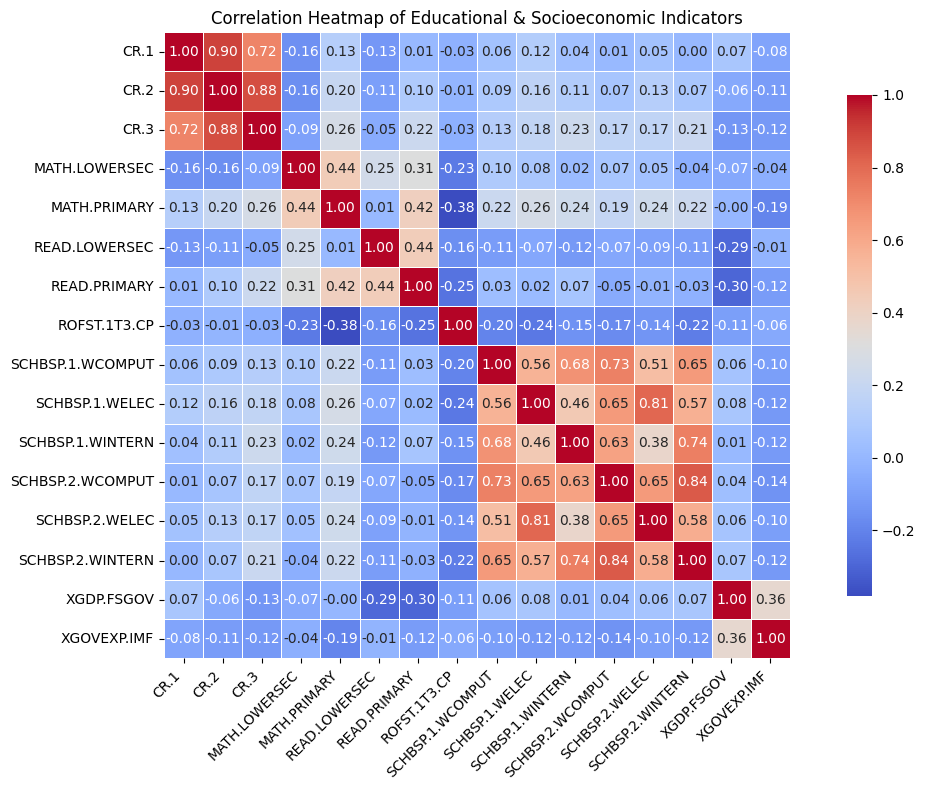

In [18]:
correlation_data = df_pivoted.select_dtypes(include='number').drop(columns=["Year"]) # Numeric indicators

#Correlation matrix
corr_matrix = correlation_data.corr()

#Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap of Educational & Socioeconomic Indicators")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 1.3  Time-series plotting for visualization of indicators evolution

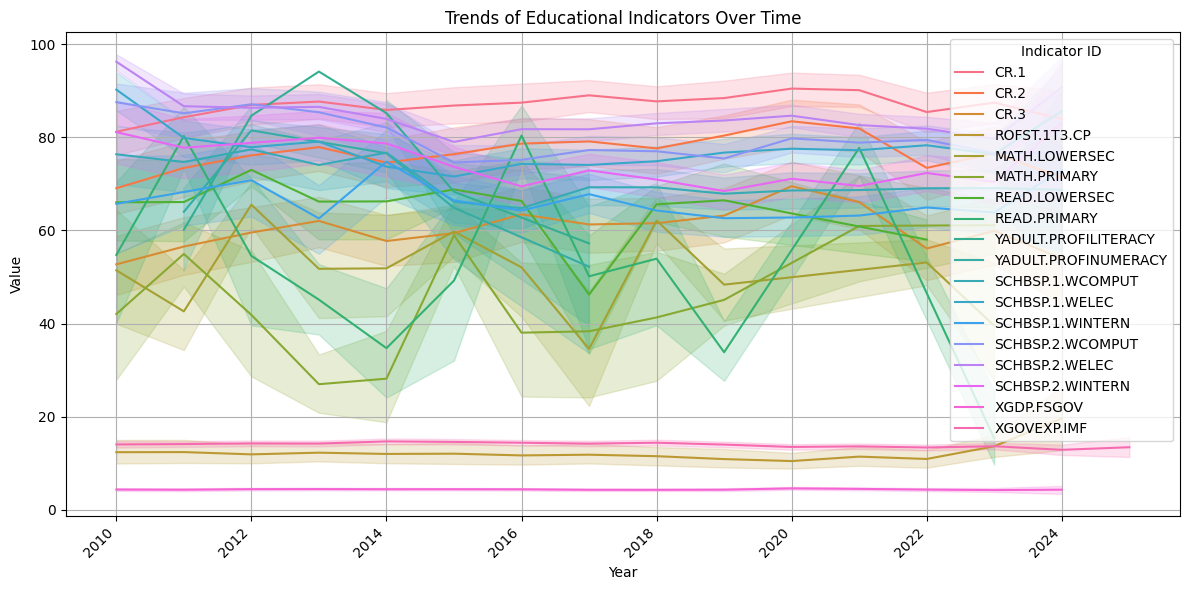

In [19]:
import seaborn as sns

#Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Value', hue='Indicator ID', data=df) # using the original dataframe for the lineplot
plt.title('Trends of Educational Indicators Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(True)
plt.show()

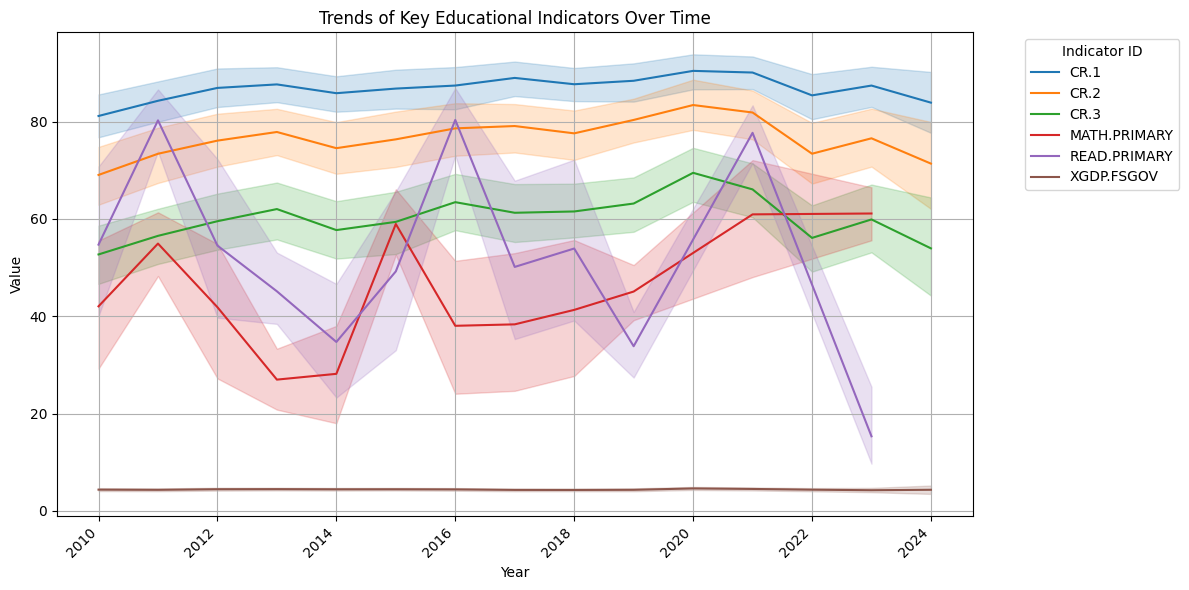

In [20]:
# Second visualization
key_indicators = ["CR.1", "CR.2", "CR.3", "MATH.PRIMARY", "READ.PRIMARY", "XGDP.FSGOV"]  #Selecting specific key indicators to improve visualization
df_filtered = df[df['Indicator ID'].isin(key_indicators)]


# Time-series visualization with improved interpretability
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Value', hue='Indicator ID', data=df_filtered)
plt.title('Trends of Key Educational Indicators Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Indicator ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

## 2. Principal Component Analysis (PCA)

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats
import numpy as np

In [22]:
df_pivoted.head()

,Geo-location,Year,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,SCHBSP.1.WCOMPUT,SCHBSP.1.WELEC,SCHBSP.1.WINTERN,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF
9,ABW,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,72.700768,92.638023,62.125891,89.010620,96.951763,85.714287,4.435037,19.401427
20,AFG,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,8.958700,16.120180,62.125891,10.305880,20.494120,85.714287,4.435037,19.401427
31,AGO,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,8.958700,16.120180,62.125891,10.305880,20.494120,85.714287,2.073064,6.045356
47,AIA,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2.812935,11.119861
61,AIMS: Asia and the Pacific,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,38.939571,75.693619,35.130692,53.968521,84.693298,37.978230,2.812935,11.119861


Index(['Geo-location', 'Year', 'CR.1', 'CR.2', 'CR.3', 'MATH.LOWERSEC',
       'MATH.PRIMARY', 'READ.LOWERSEC', 'READ.PRIMARY', 'ROFST.1T3.CP',
       'SCHBSP.1.WCOMPUT', 'SCHBSP.1.WELEC', 'SCHBSP.1.WINTERN',
       'SCHBSP.2.WCOMPUT', 'SCHBSP.2.WELEC', 'SCHBSP.2.WINTERN', 'XGDP.FSGOV',
       'XGOVEXP.IMF'],
      dtype='object')


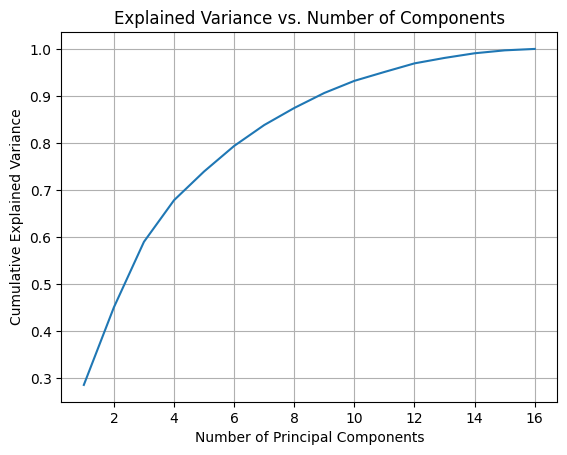

In [23]:
# Method: PCA (Principal Component Analysis)
# PCA reduces the dimensionality of the data by creating new uncorrelated features.
# Using the explained variance ratio to see how much each PC explains the variance in the data.

print(df_pivoted.columns)
X = df_pivoted.drop(columns=["Geo-location", "Year"])
#  X = data.drop(columns=["Geo-location", "Year"])

# Standardizing the data since PCA is scale-sensitive
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Imputing remaining NaNs with the mean ---
# This is done after scaling to avoid data leakage during imputation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Using mean imputation
X_scaled = imputer.fit_transform(X_scaled)

# Performing PCA on the scaled data
pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

Number of components: 9


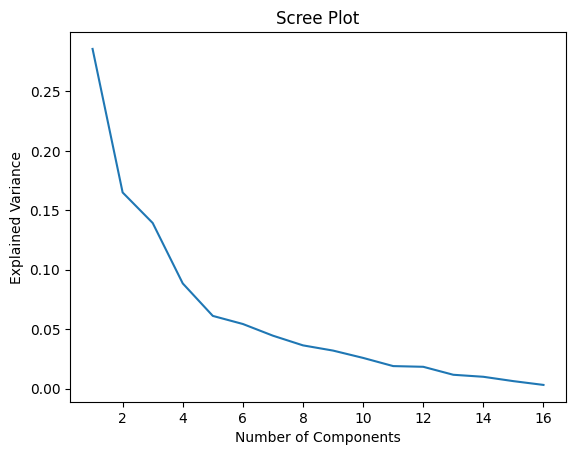

In [24]:
# Keeping components explaining at least 90% of the variance
n_components = np.argmax(cumulative_variance >= 0.90) + 1
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Number of components:", n_components)

#Scree plot
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.show()

In [25]:
# Extra | Components explaining at least 90% of the variance
threshold = 0.90
n_relevant_components = np.argmax(cumulative_variance >= threshold) + 1

# Getting the principal components (eigenvectors)
components = pca.components_

# Creating a DataFrame for the components
components_df = pd.DataFrame(components, columns=X.columns[:components.shape[1]]) # using X.columns to get the correct column names
relevant_components_df = components_df.iloc[:n_relevant_components]

print(relevant_components_df)

       CR.1      CR.2      CR.3  MATH.LOWERSEC  MATH.PRIMARY  READ.LOWERSEC  \
0  0.122420  0.161426  0.199462       0.047307      0.203390      -0.056630   
1  0.530428  0.557904  0.504849      -0.108587      0.093936      -0.018867   
2 -0.127422 -0.080043 -0.003168       0.437355      0.364634       0.426078   
3  0.126771  0.041434 -0.014206       0.217867      0.269016      -0.123684   
4  0.021569  0.053695  0.097192      -0.303417     -0.438095       0.580990   
5  0.057947  0.039271 -0.062507       0.074443     -0.095027       0.205774   
6  0.000819  0.047049  0.114984       0.529068      0.002987       0.023283   
7 -0.263778 -0.082010  0.062189      -0.445112      0.279225      -0.345362   
8  0.056907 -0.046615 -0.069878      -0.194802      0.069953       0.371690   

   READ.PRIMARY  ROFST.1T3.CP  SCHBSP.1.WCOMPUT  SCHBSP.1.WELEC  \
0      0.052570     -0.145576          0.370148        0.371576   
1      0.123997      0.047106         -0.139675       -0.086942   
2      0

In [26]:
# Applying PCA with determined number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

## 3.Optimal Number of Clusters (Elbow & Silhouette Methods)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
!pip install kneed
from kneed import KneeLocator # For automatic elbow(/ knee) point detection
import pandas as pd
from sklearn.decomposition import PCA
from scipy import stats

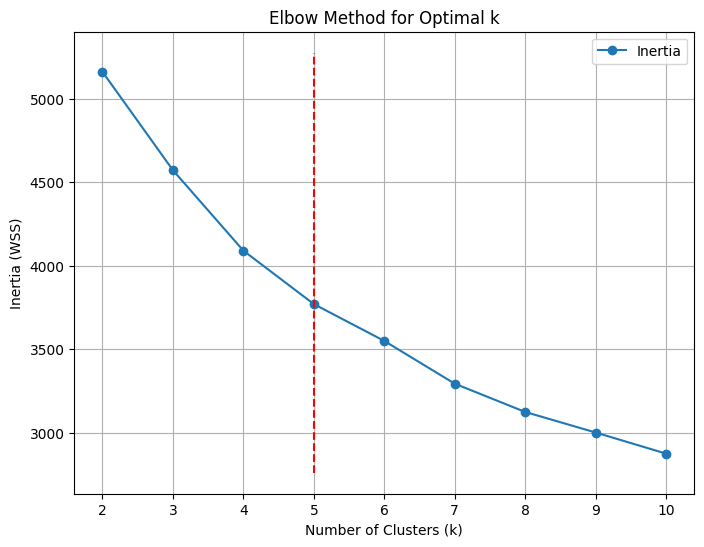

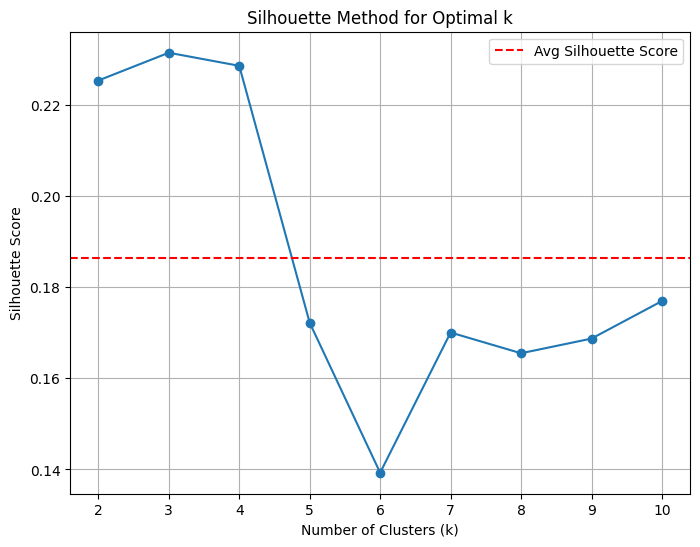

Optimal k (Elbow - Knee Point): 5
Optimal k (Silhouette): 3


In [28]:
# --- Finding Optimal Number of Clusters k ---
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# --- Elbow Plot with Knee Point Detection ---
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o', label='Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.legend()

# Using KneeLocator (extra)
knee = KneeLocator(k_range, inertia, curve="convex", direction="decreasing")
optimal_k_elbow = knee.elbow
plt.vlines(optimal_k_elbow, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='r', label='Elbow Point')
plt.show()

# --- Silhouette Plot ---
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.axhline(y=np.mean(silhouette_scores), color='r', linestyle='--', label='Avg Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.legend()
plt.show()

# --- Determining Optimal k ---
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Optimal k (Elbow - Knee Point): {optimal_k_elbow}")
print(f"Optimal k (Silhouette): {optimal_k_silhouette}")

## 3.1 K-Means Clustering

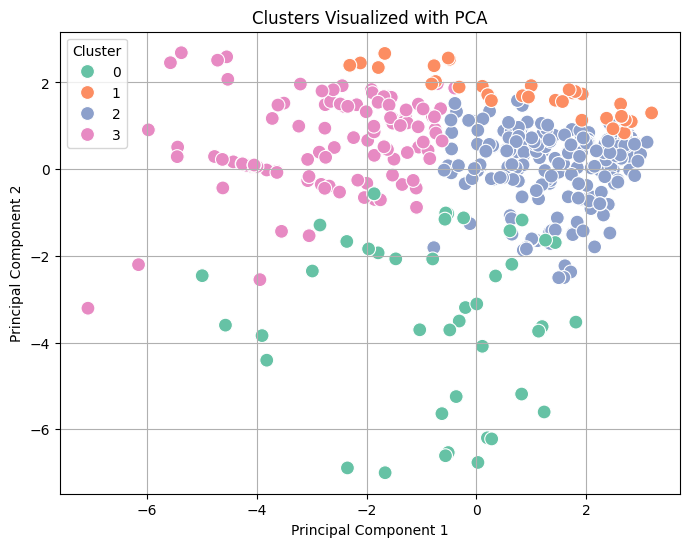

In [29]:
# --- Cluster Visualization using PCA ---
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


optimal_k = 4 # Based on Elbow (suggesting k=5) and Silhouette (suggesting k=3), k=4 was selected for balance

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Cluster labels
cluster_labels = kmeans.labels_

# PCA for visualization
pca = PCA(n_components=2)  #Reducing to 2 dimensions for visualization
X_pca = pca.fit_transform(StandardScaler().fit_transform(df_pivoted.drop(columns=["Geo-location", "Year"])))
#X_pca = pca.fit_transform(X_scaled)

#Adding the 'Cluster' column to df_pivoted
df_pivoted['Cluster'] = cluster_labels

#Creating a dataframe
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': cluster_labels
})

#Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title('Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

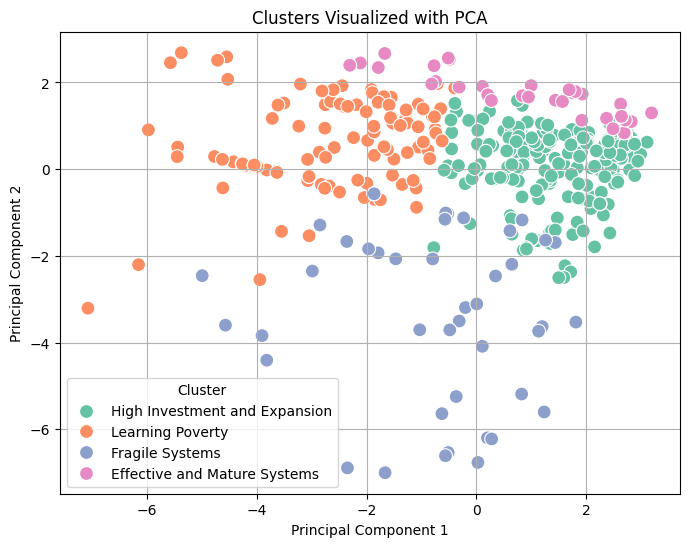

In [30]:
#Renaming Clusters
cluster_names = {
       0: "Fragile Systems",
       1: "Effective and Mature Systems",
       2: "High Investment and Expansion",
       3: "Learning Poverty"
   }

#Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2',
                   hue=pca_df['Cluster'].map(cluster_names),
                   palette='Set2', s=100)
plt.title('Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


In [31]:
df_pivoted['Cluster'].value_counts()

,count
Cluster,
2,216
3,113
0,43
1,35


## 3.2 Cluster Information

In [32]:
# Top and Bottom Countries based on a Key Indicator ( Key Overview)

# Example: Across all Completion Rates Levels
cluster_data = df_pivoted
if all(col in cluster_data.columns for col in ['CR.1', 'CR.2', 'CR.3']):
    print("\nTop countries based on CR levels:")
    print(cluster_data.sort_values(by=['CR.1', 'CR.2', 'CR.3'], ascending=False)['Geo-location'].head(5).to_string(index=False))

    print("\nBottom countries based on CR Levels:")
    print(cluster_data.sort_values(by=['CR.1'])['Geo-location'].head(5).to_string(index=False))
else:
    print("Columns 'CR.1', 'CR.2', or 'CR.3' not found in cluster_data for this cluster.")


Top countries based on CR levels:
                           RUS
                           RWA
                           SAU
SDG: Australia and New Zealand
             SDG: Central Asia

Bottom countries based on CR Levels:
      TGO
      TCD
      CAF
      CAN
CECC-SICA


In [33]:
#  Across Math Proficiency Levels (Primary and Lower Secondary)
cluster_data = df_pivoted
if all(col in cluster_data.columns for col in ['MATH.PRIMARY', 'MATH.LOWERSEC']):
    print("\nTop countries based on Math Proficiency (Primary & Lower Secondary):")
    print(cluster_data.sort_values(by=['MATH.PRIMARY', 'MATH.LOWERSEC'], ascending=False)['Geo-location'].head(5).to_string(index=False))

    print("\nBottom countries based on Math Proficiency (Primary):")
    print(cluster_data.sort_values(by=['MATH.PRIMARY'])['Geo-location'].head(5).to_string(index=False))
else:
    print("Columns 'MATH.PRIMARY' or 'MATH.LOWERSEC' not found in cluster_data for this cluster.")


Top countries based on Math Proficiency (Primary & Lower Secondary):
HKG
SGP
SLB
SLE
KOR

Bottom countries based on Math Proficiency (Primary):
                                 TCD
           ECA: EAC (UNSDCode:98114)
         ECA: ECCAS (UNSDCode:98107)
ECA: Central Africa (UNSDCode:98101)
        ECA: COMESA (UNSDCode:98113)


In [34]:
# Across Reading Proficiency Levels (Primary and Lower Secondary)
cluster_data = df_pivoted
if all(col in cluster_data.columns for col in ['READ.PRIMARY', 'READ.LOWERSEC']):
    print("\nTop countries based on Reading Proficiency (Primary & Lower Secondary):")
    print(cluster_data.sort_values(by=['READ.PRIMARY', 'READ.LOWERSEC'], ascending=False)['Geo-location'].head(5).to_string(index=False))

    print("\nBottom countries based on Reading Proficiency (Primary):")
    print(cluster_data.sort_values(by=['READ.PRIMARY'])['Geo-location'].head(5).to_string(index=False))
else:
    print("Columns 'READ.PRIMARY' or 'READ.LOWERSEC' not found in cluster_data for this cluster.")


Top countries based on Reading Proficiency (Primary & Lower Secondary):
                  SDG: Europe and Northern America
SDG: Europe, Northern America, Australia and Ne...
              SDG: Landlocked Developing Countries
                       WB: High income (July 2024)
                                     WB: IBRD only

Bottom countries based on Reading Proficiency (Primary):
LBN
LAO
MCO
MDA
MAC


In [35]:
# Out-of-school Rate
cluster_data = df_pivoted
if 'ROFST.1T3.CP' in cluster_data.columns:
    print("\nCountries with the highest Out-of-school Rate:")
    print(cluster_data.sort_values(by=['ROFST.1T3.CP'], ascending=False)['Geo-location'].head(5).to_string(index=False))

    print("\nCountries with the lowest Out-of-school Rate:")
    print(cluster_data.sort_values(by=['ROFST.1T3.CP'])['Geo-location'].head(5).to_string(index=False))
else:
    print("Column 'ROFST.1T3.CP' not found in cluster_data for this cluster.")


Countries with the highest Out-of-school Rate:
NGA
NER
NIU
NIC
TCD

Countries with the lowest Out-of-school Rate:
SGP
PRT
PRY
IRN
IRL


In [36]:
# Government Expenditure on Education
cluster_data = df_pivoted
if 'XGDP.FSGOV' in cluster_data.columns:
    print("\nCountries with the highest Government Expenditure on Education:")
    print(cluster_data.sort_values(by=['XGDP.FSGOV'], ascending=False)['Geo-location'].head(5).to_string(index=False))

    print("\nCountries with the lowest Government Expenditure on Education:")
    print(cluster_data.sort_values(by=['XGDP.FSGOV'])['Geo-location'].head(5).to_string(index=False))
else:
    print("Column 'XGDP.FSGOV' not found in cluster_data for this cluster.")


Countries with the highest Government Expenditure on Education:
KIR
FSM
MHL
MKD
NCL

Countries with the lowest Government Expenditure on Education:
SOM
NGA
PNG
IDN
HTI


In [37]:
# Summary of Key Characteristics in each cluster with Average Values per indicator
numerical_features = [col for col in df_pivoted.select_dtypes(include=np.number).columns if col not in ['Year', 'Cluster']]
df_pivoted.groupby('Cluster')[numerical_features].mean().round(2)

,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,SCHBSP.1.WCOMPUT,SCHBSP.1.WELEC,SCHBSP.1.WINTERN,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF
Cluster,,,,,,,,,,,,,,,,
0,64.47,47.21,28.42,50.90,29.58,70.08,34.05,13.38,69.26,78.65,63.24,83.66,89.93,77.40,3.20,13.93
1,99.35,98.24,91.21,61.14,84.02,69.86,86.09,5.44,71.68,76.22,71.90,74.16,81.05,68.38,1.99,10.92
2,97.22,90.39,74.14,42.49,43.45,63.34,24.70,14.06,82.71,92.78,75.96,93.40,96.58,89.51,4.34,13.67
3,94.44,84.05,60.62,36.87,23.48,63.99,23.81,20.40,36.80,52.29,32.22,45.33,66.05,35.63,3.99,14.68


In [38]:
# Option 2

def display_cluster_info(df_pivoted, optimal_k, numerical_features):
    cluster_countries = {
        cluster: df_pivoted[df_pivoted['Cluster'] == cluster]['Geo-location'].unique().tolist()
        for cluster in range(optimal_k)
    }

    for cluster, countries in cluster_countries.items():
        print(f"\nCluster {cluster} ({len(countries)} countries):")

        # Sort countries alphabetically
        countries.sort()

        # Print limited number of countries + ellipsis if too many
        if len(countries) > 10:
            print(", ".join(countries[:10]) + ", ...")
        else:
            print(", ".join(countries))

        # Calculate cluster centroid (mean values)
        centroid = df_pivoted[df_pivoted['Cluster'] == cluster][numerical_features].mean()
        print("\nCluster Centroid:")
        for feature, value in centroid.items():
            print(f"  {feature}: {value:.2f}")


numerical_features = [col for col in df_pivoted.select_dtypes(include=np.number).columns if col != 'Year']
display_cluster_info(df_pivoted, optimal_k, numerical_features)


Cluster 0 (43 countries):
BEN, CAF, CAN, CECC-SICA, ETH, GPE: Rest of the World GPE Secretariat, December 2023, GPE: Small island and landlocked developing states, December 2023, GPE: South Asia WB FY23, December 2023, GPE: Upper middle Income WB FY23, December 2023, KHM, ...

Cluster Centroid:
  CR.1: 64.47
  CR.2: 47.21
  CR.3: 28.42
  MATH.LOWERSEC: 50.90
  MATH.PRIMARY: 29.58
  READ.LOWERSEC: 70.08
  READ.PRIMARY: 34.05
  ROFST.1T3.CP: 13.38
  SCHBSP.1.WCOMPUT: 69.26
  SCHBSP.1.WELEC: 78.65
  SCHBSP.1.WINTERN: 63.24
  SCHBSP.2.WCOMPUT: 83.66
  SCHBSP.2.WELEC: 89.93
  SCHBSP.2.WINTERN: 77.40
  XGDP.FSGOV: 3.20
  XGOVEXP.IMF: 13.93
  Cluster: 0.00

Cluster 1 (35 countries):
GBR, SDG: Europe and Northern America, SDG: Europe, Northern America, Australia and New Zealand, VNM, VUT, WB: Africa Eastern and Southern, WB: Africa Western and Central, WB: Arab World, WB: Caribbean small states, WB: Central Europe and the Baltics, ...

Cluster Centroid:
  CR.1: 99.35
  CR.2: 98.24
  CR.3: 91.

In [39]:
# This code snippet aims to identify and display specific countries and the cluster they belong

#Example: Latin American country codes
latin_america_codes = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'CRI', 'CUB', 'DOM', 'ECU', 'SLV', 'GTM',
    'HND', 'HTI', 'JAM', 'MEX', 'NIC', 'PAN', 'PRY', 'PER', 'URY', 'VEN',
]

latam_clusters = df_pivoted[df_pivoted['Geo-location'].isin(latin_america_codes)][['Geo-location', 'Cluster']]
print(latam_clusters)

     Geo-location  Cluster
215           ARG        2
469           BOL        2
483           BRA        2
607           CHL        2
704           COL        2
746           CRI        2
760           CUB        2
881           DOM        2
1245          ECU        2
2114          GTM        3
2154          HND        2
2179          HTI        2
2309          JAM        2
2864          MEX        2
3082          NIC        3
3199          PAN        3
3213          PER        2
3311          PRY        2
3763          SLV        3
4484          URY        2


In [40]:
# Descriptive Statistics of Each Cluster (Overall)
numerical_features = [col for col in df_pivoted.select_dtypes(include=np.number).columns if col not in ['Year', 'Cluster']]

for cluster_num in range(optimal_k):
    print(f"\nCluster {cluster_num} Information:")

    # Filtering data for the current cluster
    cluster_data = df_pivoted[df_pivoted['Cluster'] == cluster_num][numerical_features]

    # Key Statistics for the Cluster (Mean, Median, Std, Min, Max)
    print(f"  Mean: {cluster_data.mean().mean():.2f}")  # Average across all indicators
    print(f"  Median: {cluster_data.median().median():.2f}")  # Median across all indicators
    print(f"  Standard Deviation: {cluster_data.std().std():.2f}")  # Std Dev across all indicators


Cluster 0 Information:
  Mean: 51.09
  Median: 52.84
  Standard Deviation: 9.06

Cluster 1 Information:
  Mean: 65.73
  Median: 78.64
  Standard Deviation: 10.48

Cluster 2 Information:
  Mean: 62.42
  Median: 80.00
  Standard Deviation: 8.06

Cluster 3 Information:
  Mean: 43.41
  Median: 34.37
  Standard Deviation: 8.21


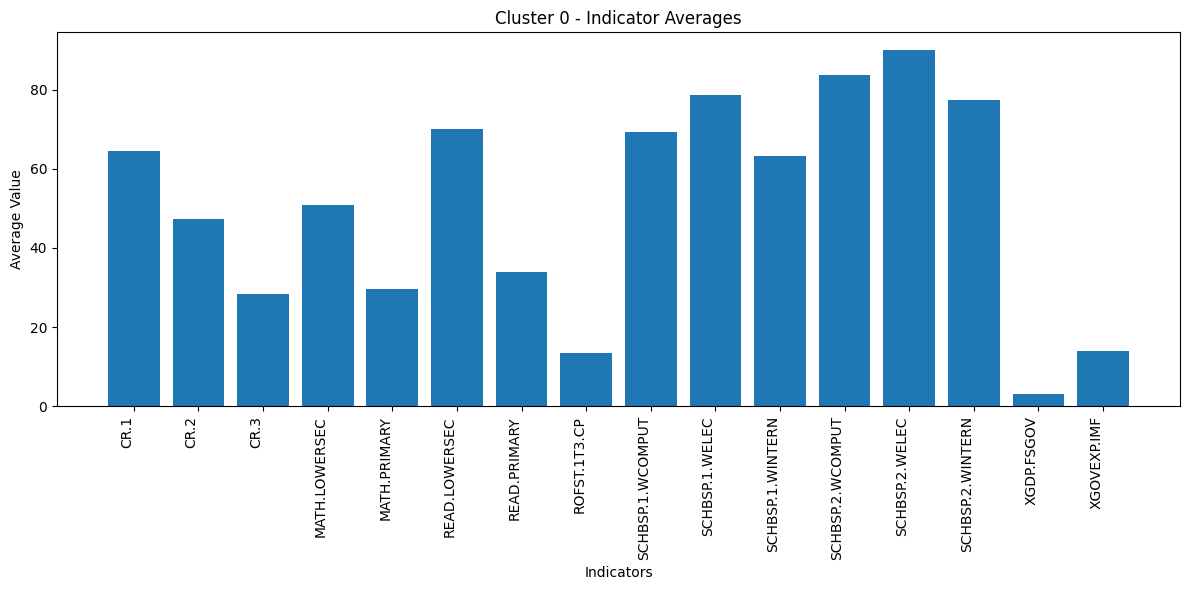

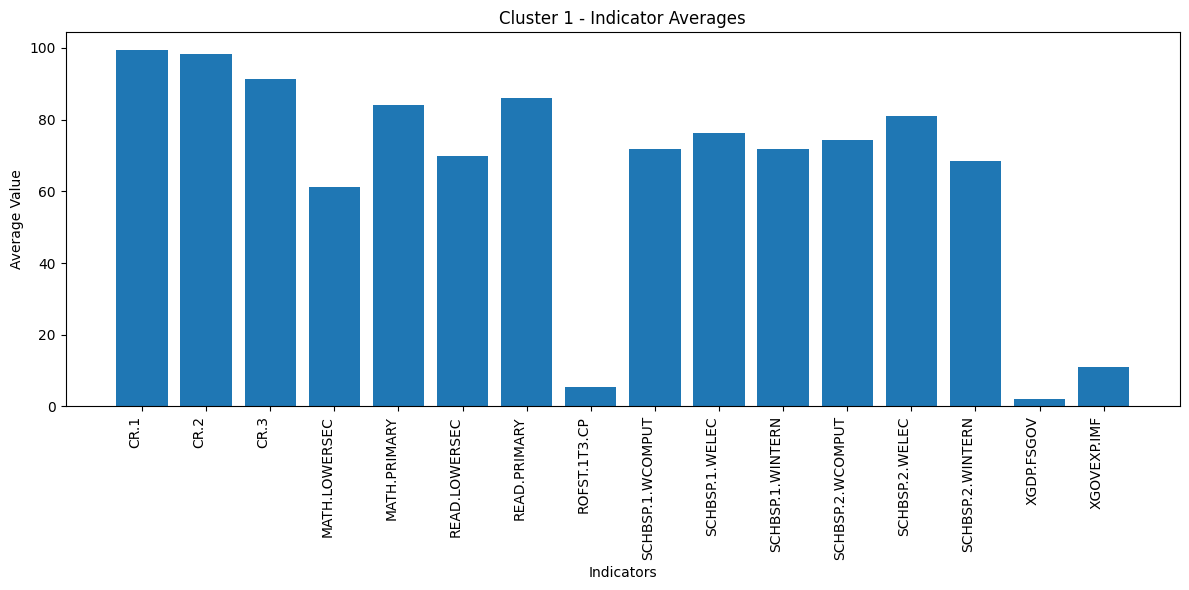

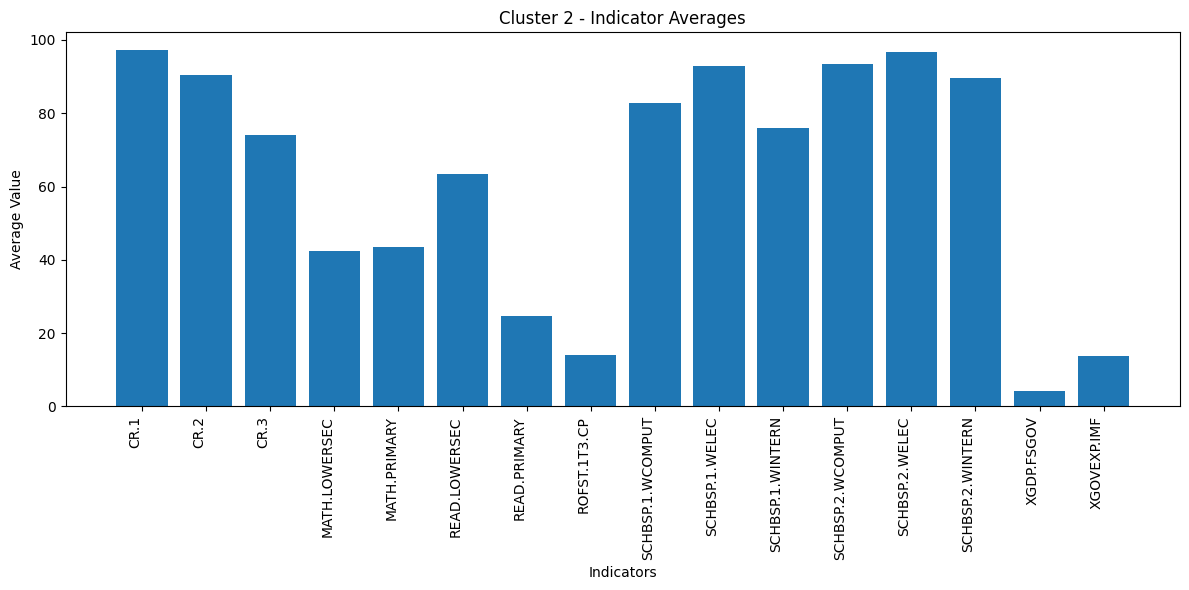

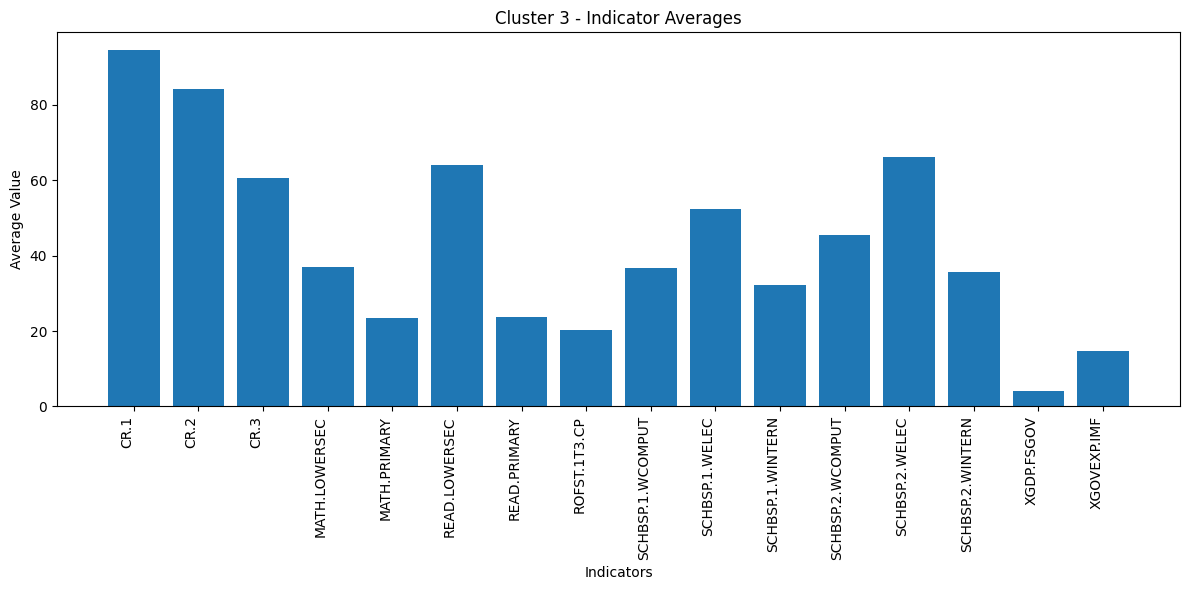

In [41]:
# Getting numerical features for plotting
numerical_features = [
    col for col in df_pivoted.select_dtypes(include=np.number).columns
    if col not in ["Year", "Cluster"]
]

# Extracting mean values of each indicator for each cluster
cluster_means = df_pivoted.groupby("Cluster")[numerical_features].mean()



# Iteration through each cluster
for cluster in range(optimal_k):
    # Getting data for the current cluster
    cluster_data = cluster_means.loc[cluster]

    # Bar plot
    plt.figure(figsize=(12, 6))
    plt.bar(
        cluster_data.index, cluster_data.values
    )
    plt.title(f"Cluster {cluster} - Indicator Averages")
    plt.xlabel("Indicators")
    plt.ylabel("Average Value")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.show()

<Figure size 1600x800 with 0 Axes>

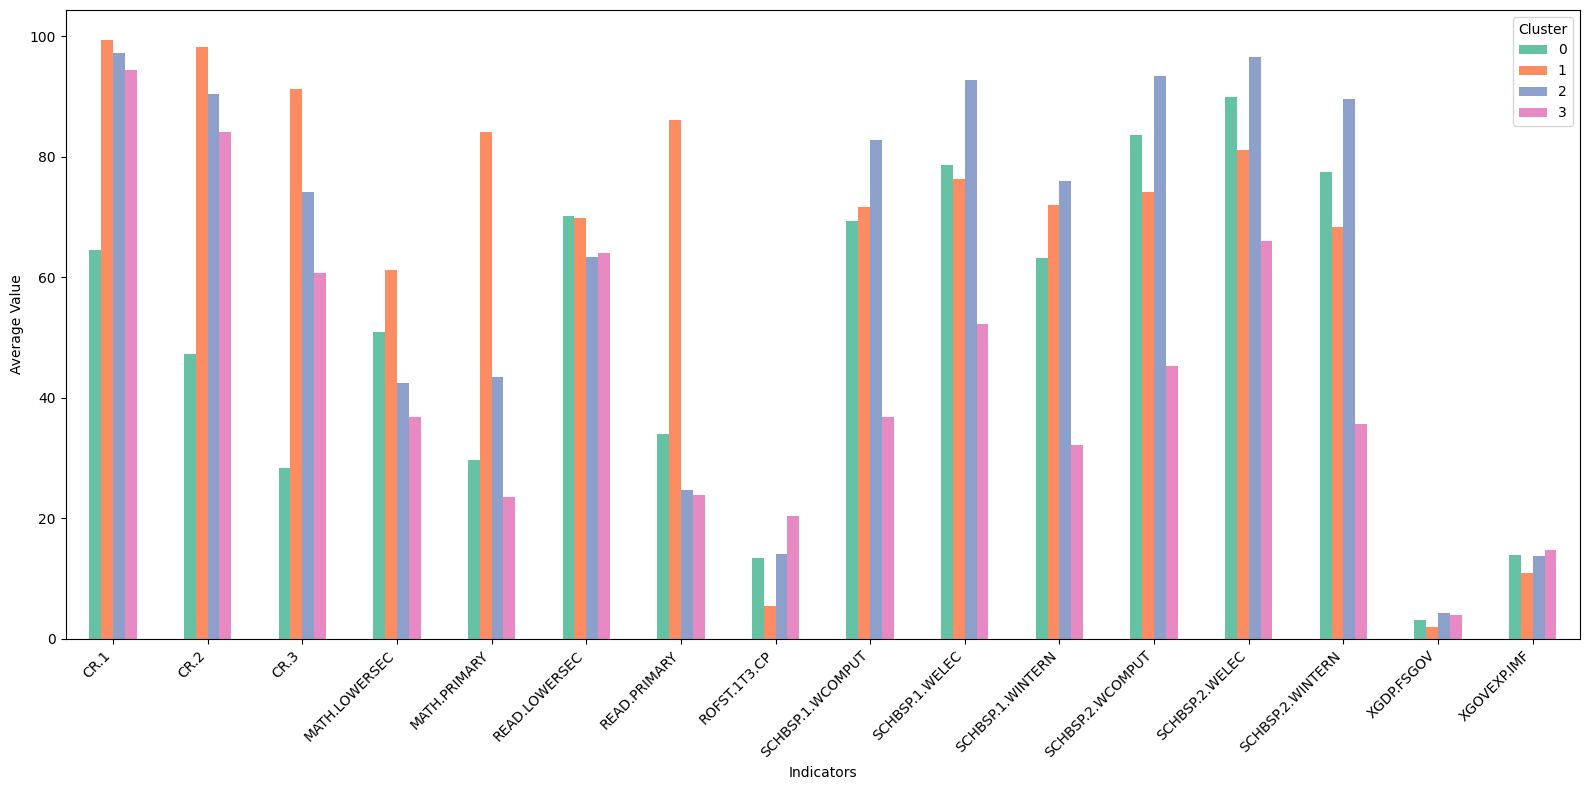

In [42]:
# Clusters' Indicators comparison
numerical_features = [col for col in df_pivoted.columns if col not in ['Geo-location', 'Cluster', 'Year']]
cluster_means = df_pivoted.groupby('Cluster')[numerical_features].mean() # extracted already above but adding it again for reference

# Transposing for grouped bar chart format
cluster_means_t = cluster_means.T


# Plot
plt.figure(figsize=(16, 8))
colors = sns.color_palette("Set2", n_colors=4)
cluster_means_t.plot(kind='bar', figsize=(16, 8), color=colors)

plt.xlabel('Indicators')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()






In [43]:
df_pivoted.head()

,Geo-location,Year,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,SCHBSP.1.WCOMPUT,SCHBSP.1.WELEC,SCHBSP.1.WINTERN,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF,Cluster
9,ABW,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,72.700768,92.638023,62.125891,89.010620,96.951763,85.714287,4.435037,19.401427,2
20,AFG,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,8.958700,16.120180,62.125891,10.305880,20.494120,85.714287,4.435037,19.401427,3
31,AGO,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,8.958700,16.120180,62.125891,10.305880,20.494120,85.714287,2.073064,6.045356,3
47,AIA,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2.812935,11.119861,2
61,AIMS: Asia and the Pacific,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,38.939571,75.693619,35.130692,53.968521,84.693298,37.978230,2.812935,11.119861,3


## 4. Post Hoc Analysis

In [44]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Load teacher indicators
df_professors = pd.read_csv('dataprofessors.csv')

# Standardize column name
df_professors.rename(columns={'geoUnit': 'Geo-location'}, inplace=True)

# Filter only the indicators of interest
selected_ids = ['PTRHC.1.TRAINED', 'PTRHC.1.QUALIFIED', 'TATTRR.1']
teacher_filtered = df_professors[df_professors['indicatorId'].isin(selected_ids)]

# Pivot so each indicator becomes a column
teacher_pivot = teacher_filtered.pivot_table(
    index=['Geo-location', 'year'],
    columns='indicatorId',
    values='value'
).reset_index()


# Merge with df_pivoted based on 'Geo-location'
df_merged = pd.merge(df_pivoted, teacher_pivot, on='Geo-location', how='left')


In [45]:
df_merged.head()

,Geo-location,Year,CR.1,CR.2,CR.3,MATH.LOWERSEC,MATH.PRIMARY,READ.LOWERSEC,READ.PRIMARY,ROFST.1T3.CP,...,SCHBSP.2.WCOMPUT,SCHBSP.2.WELEC,SCHBSP.2.WINTERN,XGDP.FSGOV,XGOVEXP.IMF,Cluster,year,PTRHC.1.QUALIFIED,PTRHC.1.TRAINED,TATTRR.1
0,ABW,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,...,89.01062,96.951763,85.714287,4.435037,19.401427,2,2010.0,NaN,16.822531,NaN
1,ABW,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,...,89.01062,96.951763,85.714287,4.435037,19.401427,2,2011.0,NaN,15.111110,NaN
2,ABW,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,...,89.01062,96.951763,85.714287,4.435037,19.401427,2,2012.0,NaN,14.862880,NaN
3,AFG,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,...,10.30588,20.494120,85.714287,4.435037,19.401427,3,2016.0,58.64962,NaN,NaN
4,AFG,2019,98.513206,90.5,74.2,32.508819,32.34716,63.52148,22.2,8.68039,...,10.30588,20.494120,85.714287,4.435037,19.401427,3,2017.0,63.12466,NaN,NaN


Geo-location            0
Year                    0
CR.1                    0
CR.2                    0
CR.3                    0
MATH.LOWERSEC           0
MATH.PRIMARY            0
READ.LOWERSEC           0
READ.PRIMARY            0
ROFST.1T3.CP            0
SCHBSP.1.WCOMPUT        0
SCHBSP.1.WELEC          0
SCHBSP.1.WINTERN        0
SCHBSP.2.WCOMPUT        0
SCHBSP.2.WELEC          0
SCHBSP.2.WINTERN        0
XGDP.FSGOV              0
XGOVEXP.IMF             0
Cluster                 0
year                   51
PTRHC.1.QUALIFIED    1021
PTRHC.1.TRAINED       480
TATTRR.1             3014
dtype: int64


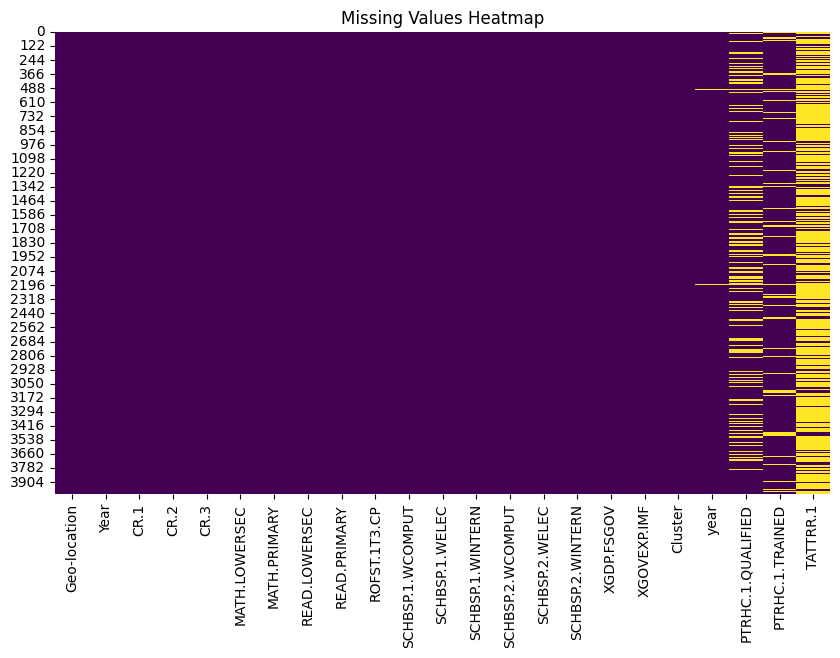

In [46]:
# Check for missing values in the combined dataframe
missing_values = df_merged.isnull().sum()
print(missing_values)

# Visualize missing values (optional)
plt.figure(figsize=(10, 6))
sns.heatmap(df_merged.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

# Step 1: Define features and target
features = [
    'ROFST.1T3.CP',
    'XGDP.FSGOV',
    'PTRHC.1.TRAINED',  # or 'Trained_Teachers_Primary' if already renamed
    'SCHBSP.1.WINTERN'
]
target = 'MATH.PRIMARY'
cols = features + [target]

# Standardizing the data before imputation
scaler = StandardScaler()
X_scaled_for_imputation = scaler.fit_transform(df_merged[cols])

# Aplying KNN imputation
imputer = KNNImputer(n_neighbors=5)
X_imputed_scaled = imputer.fit_transform(X_scaled_for_imputation)

# Inverse transform to return to original scale
X_imputed = scaler.inverse_transform(X_imputed_scaled)

# Replacing in dataframe
df_merged[cols] = pd.DataFrame(X_imputed, columns=cols)


In [48]:
df_merged[features + [target]].isnull().sum()

,0
ROFST.1T3.CP,0
XGDP.FSGOV,0
PTRHC.1.TRAINED,0
SCHBSP.1.WINTERN,0
MATH.PRIMARY,0


In [49]:
import statsmodels.api as sm

def display_coefficients_by_cluster_statsmodels(df_merged, features, target):
    all_coefficients = []  # Initialize a list to store coefficients for all clusters
    for cluster in range(optimal_k):
        # Filter data for the current cluster using df_merged
        cluster_data = df_merged[df_merged["Cluster"] == cluster]
        X = cluster_data[features]
        y = cluster_data[target]

        # Add a constant for the intercept
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()
        print(f"\nCluster {cluster} Coefficients:")
        print(model.summary())  # or print(model.params) for just coefficients

        # Append coefficients to the list
        for feature, coef in model.params.items():
            all_coefficients.append({'Cluster': cluster, 'Feature': feature, 'Coefficient': coef})

    return all_coefficients  # Return the list of coefficients

# Get coefficients
coefficients = display_coefficients_by_cluster_statsmodels(df_merged, features, target)



Cluster 0 Coefficients:
                            OLS Regression Results                            
Dep. Variable:           MATH.PRIMARY   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     11.85
Date:                Fri, 09 May 2025   Prob (F-statistic):           3.68e-09
Time:                        16:06:03   Log-Likelihood:                -2124.9
No. Observations:                 454   AIC:                             4260.
Df Residuals:                     449   BIC:                             4280.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const          

In [50]:
#summary
coef_df = pd.DataFrame(coefficients)
coef_df = coef_df[coef_df["Feature"] == "PTRHC.1.TRAINED"]
display(coef_df)

,Cluster,Feature,Coefficient
3,0,PTRHC.1.TRAINED,-0.280351
8,1,PTRHC.1.TRAINED,0.129920
13,2,PTRHC.1.TRAINED,0.043097
18,3,PTRHC.1.TRAINED,-0.174884


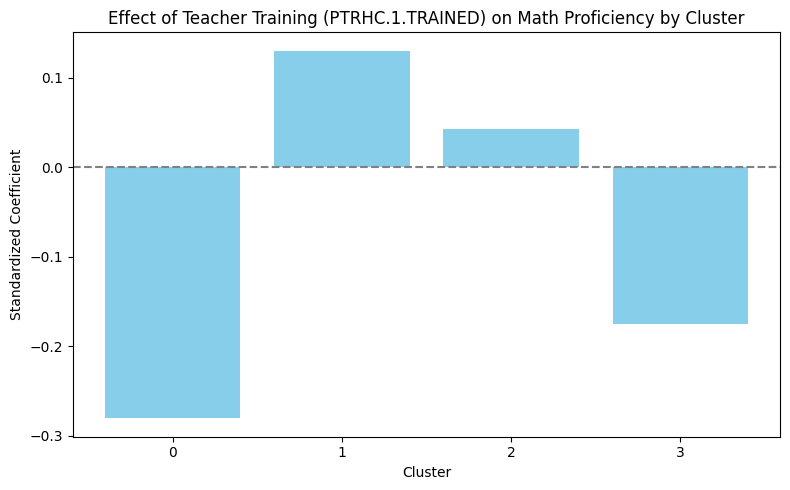

In [51]:
# Convert coefficient dictionary to DataFrame
coef_df = pd.DataFrame(coefficients)  # Use the returned coefficients
coef_df = coef_df[coef_df['Feature'] == 'PTRHC.1.TRAINED']

# Plot
plt.figure(figsize=(8, 5))
plt.bar(coef_df['Cluster'].astype(str), coef_df['Coefficient'], color='skyblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Effect of Teacher Training (PTRHC.1.TRAINED) on Math Proficiency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

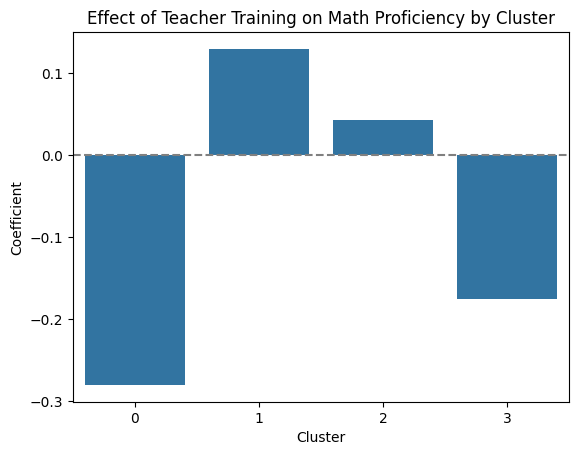

In [54]:
sns.barplot(data=coef_df, x="Cluster", y="Coefficient")
plt.axhline(0, color='gray', linestyle='--')
plt.title("Effect of Teacher Training on Math Proficiency by Cluster")
plt.show()